# Removed Data Points Messages

Small examples for checking computation messages from geoms, sampling and stats.

Contours are intentionally not included: they do not currently drop input rows in the same way as the stats below.


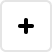
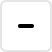
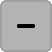
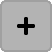
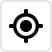
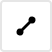
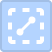
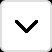
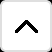
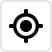
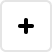
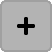
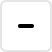
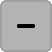
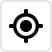
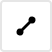
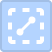
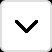
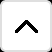
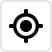

In [1]:
import numpy as np
import pandas as pd

from lets_plot import *

LetsPlot.setup_html()

In [2]:
df_x = pd.DataFrame({
    "x": [1, 2, np.nan, 4, 5, np.nan]
})

df_xy = pd.DataFrame({
    "x": [1, 2, np.nan, 4, 5, np.nan],
    "y": [2, np.nan, 3, 4, 5, np.nan],
    "w": [1, 1, 1, np.nan, 1, 1],
    "g": ["A", "A", "A", "B", "B", "B"]
})

df_qq2 = pd.DataFrame({
    "x": [4, np.nan, 1, 9, 6, 2, 10, np.nan, 7, 5],
    "y": [7, 1, 9, 10, 4, np.nan, 3, np.nan, 6, 5]
})

df_smooth = pd.DataFrame({
    "x": [1, 2, 3, 4, 5, 6, 7, 8],
    "y": [1, np.nan, 3, 4, 5, np.nan, 7, 8]
})

df_ridges = pd.DataFrame({
    "x": [1, 2, np.nan, 4, 1, 2, 3, np.nan],
    "y": [0, 0, 0, 0, 1, 1, 1, 1]
})

df_sampling = pd.DataFrame({
    "x": list(range(10)),
    "y": list(range(10))
})

## Count / Count2d

In [3]:
ggplot(df_x, aes("x")) + geom_bar()

In [4]:
ggplot(df_xy, aes("x", "y")) + geom_pie()

## Bin / Bin2d / Binhex

In [5]:
ggplot(df_x, aes("x")) + geom_histogram(bins=4)

In [6]:
ggplot(df_xy, aes("x", "y")) + geom_bin2d(bins=[3, 3])

In [7]:
ggplot(df_xy, aes("x", "y")) + geom_hex(bins=[3, 3])

## Dotplot / YDotplot

In [8]:
ggplot(df_x, aes("x")) + geom_dotplot(binwidth=1.0)

In [9]:
ggplot(df_xy, aes("x", "y")) + geom_ydotplot(binwidth=1.0)

## Summary / Summary Bin

In [10]:
ggplot(df_xy, aes("g", "y")) + stat_summary()

In [11]:
ggplot(df_xy, aes("x", "y")) + stat_summary_bin(bins=3)

## Boxplot

`geom_boxplot()` exercises boxplot-related stats, including outlier handling.

In [12]:
ggplot(df_xy, aes("g", "y")) + geom_boxplot()

## Density Family

In [13]:
ggplot(df_x, aes("x")) + geom_density()

In [14]:
ggplot(df_xy, aes("x", "y")) + geom_density2d()

In [15]:
ggplot(df_xy, aes("x", "y")) + geom_density2df()

In [16]:
ggplot(df_xy, aes("g", "y")) + geom_violin()

In [17]:
ggplot(df_xy, aes("g", "y")) + geom_sina()

In [18]:
ggplot(df_ridges, aes("x", "y")) + geom_area_ridges()

## ECDF

In [19]:
ggplot(df_x, aes("x")) + stat_ecdf()

## QQ / QQ Line

In [20]:
ggplot(df_x, aes(sample="x")) + geom_qq()

In [21]:
ggplot(df_x, aes(sample="x")) + geom_qq_line()

## QQ2 / QQ2 Line

For `qq2`/`qq2line`, a row is counted as removed only when both `x` and `y` are non-finite. In `df_qq2`, only row 8 has both values missing.

In [22]:
ggplot(df_qq2, aes("x", "y")) + geom_qq2()

In [23]:
ggplot(df_qq2, aes("x", "y")) + geom_qq2_line()

## Smooth / Smooth Summary

This example should show non-finite removal. It also uses LOESS sampling (`max_n=4`) to check the sampling message inside stat.

In [24]:
ggplot(df_smooth, aes("x", "y")) + \
    geom_smooth(method="loess", max_n=6, seed=42)

## Point Density

In [25]:
ggplot(df_xy, aes("x", "y")) + geom_pointdensity()